# ANALISIS DATA - Air Quality Data in India

## DATA UNDERSTANDING

### Import Library

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


c:\Miniconda3\envs\umum\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Data

In [2]:
path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")


### Preview Awal Dataset

In [3]:
df_city_day = pd.read_csv(path + "/city_day.csv")
df_city_day.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
df_city_hour = pd.read_csv(path + "/city_hour.csv")
df_city_hour.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.0,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.0,0.0,NaN,NaN


In [5]:
df_station_day = pd.read_csv(path + "/station_day.csv")
df_station_day.head()

,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,0.10,NaN,NaN
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate


In [6]:
df_station_hour = pd.read_csv(path + "/station_hour.csv")
df_station_hour.head()

C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_260\3766055440.py:1: DtypeWarning: Columns (0: AQI_Bucket) have mixed types. Specify dtype option on import or set low_memory=False.
  df_station_hour = pd.read_csv(path + "/station_hour.csv")


,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,0.10,NaN,NaN
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,0.08,NaN,NaN


In [7]:
df_stations = pd.read_csv(path + "/stations.csv")
df_stations.head()

,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


### Merge Dataset

- Merge dataset station_hour dengan stations berdasarkan stationID

In [8]:
df_station_hour = df_station_hour.merge(df_stations, on="StationId", how="left")
df_station_hour.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,StationName,City,State,Status
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,0.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,0.08,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [9]:
df_station_hour.info()

<class 'pandas.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 20 columns):
 #   Column       Dtype  
---  ------       -----  
 0   StationId    str    
 1   Datetime     str    
 2   PM2.5        float64
 3   PM10         float64
 4   NO           float64
 5   NO2          float64
 6   NOx          float64
 7   NH3          float64
 8   CO           float64
 9   SO2          float64
 10  O3           float64
 11  Benzene      float64
 12  Toluene      float64
 13  Xylene       float64
 14  AQI          float64
 15  AQI_Bucket   str    
 16  StationName  str    
 17  City         str    
 18  State        str    
 19  Status       str    
dtypes: float64(13), str(7)
memory usage: 395.1 MB


In [10]:
df_station_hour.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,1.941394e+06,1.469831e+06,2.035372e+06,2.060110e+06,2.098275e+06,1.352465e+06,2.089781e+06,1.846346e+06,1.863110e+06,1.727504e+06,1.546717e+06,513979.000000,2.018893e+06
mean,8.086481e+01,1.584839e+02,2.278825e+01,3.523689e+01,4.055115e+01,2.870856e+01,1.502366e+00,1.211602e+01,3.806408e+01,3.305493e+00,1.490266e+01,2.448881,1.801730e+02
std,8.947618e+01,1.397883e+02,4.846146e+01,3.497508e+01,5.590894e+01,2.753244e+01,6.292445e+00,1.467385e+01,4.710653e+01,1.214053e+01,3.329729e+01,8.973470,1.404095e+02
min,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,0.000000e+00,1.000000e-02,1.000000e-02,0.000000e+00,0.000000e+00,0.000000,5.000000e+00
25%,2.816000e+01,6.400000e+01,3.050000e+00,1.310000e+01,1.135000e+01,1.123000e+01,4.100000e-01,4.250000e+00,1.102000e+01,8.000000e-02,3.400000e-01,0.000000,8.400000e+01
50%,5.259000e+01,1.162500e+02,7.150000e+00,2.479000e+01,2.286000e+01,2.235000e+01,8.000000e-01,8.250000e+00,2.475000e+01,9.600000e-01,3.400000e+00,0.200000,1.310000e+02
75%,9.774000e+01,2.040000e+02,1.858000e+01,4.548000e+01,4.570000e+01,3.778000e+01,1.380000e+00,1.453000e+01,4.953000e+01,3.230000e+00,1.510000e+01,1.830000,2.590000e+02
max,1.000000e+03,1.000000e+03,5.000000e+02,4.999900e+02,5.000000e+02,4.999700e+02,4.985700e+02,1.999600e+02,9.970000e+02,4.980700e+02,4.999900e+02,499.990000,3.133000e+03


In [11]:
missing_values = pd.DataFrame({
    "missing_values": df_station_hour.isnull().sum(),
    "percentage": df_station_hour.isna().mean() * 100
}).reset_index().rename(columns={"index": "column_name"})
missing_values.sort_values(by="missing_values", ascending=False)
missing_values["percentage"] = missing_values["percentage"].round(2)
missing_values.sort_values(by="missing_values", ascending=False)

,column_name,missing_values,percentage
13,Xylene,2075104,80.15
7,NH3,1236618,47.76
3,PM10,1119252,43.23
12,Toluene,1042366,40.26
11,Benzene,861579,33.28
9,SO2,742737,28.69
10,O3,725973,28.04
2,PM2.5,647689,25.02
15,AQI_Bucket,570190,22.02
14,AQI,570190,22.02


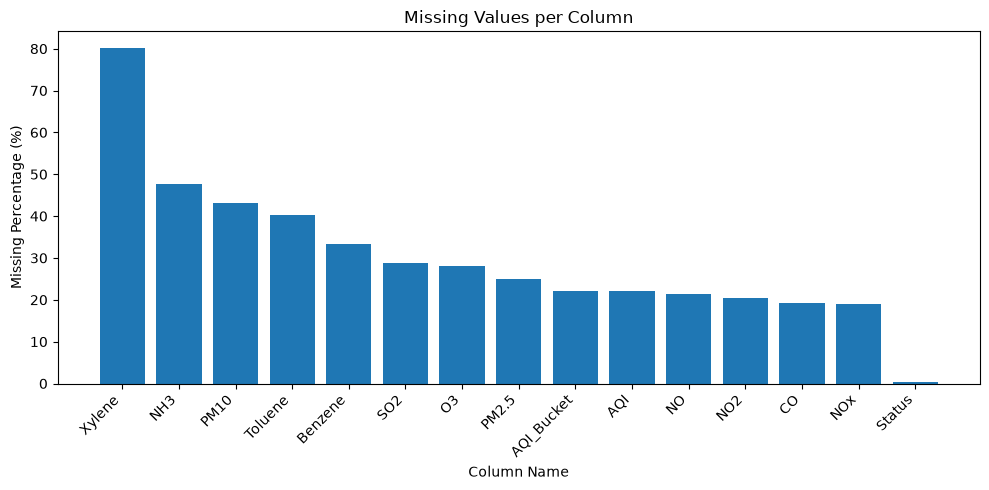

In [12]:
missing_values = pd.DataFrame({
    "column_name": df_station_hour.columns,
    "missing_values": df_station_hour.isnull().sum(),
    "percentage": df_station_hour.isna().mean() * 100
})

top10_missing = missing_values.sort_values(
    by="percentage",
    ascending=False
).head(15)

plt.figure(figsize=(10, 5))
plt.bar(top10_missing["column_name"], top10_missing["percentage"])

plt.title("Missing Values per Column")
plt.xlabel("Column Name")
plt.ylabel("Missing Percentage (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---

- merge data station_day dengan stations berdasarkan stationId 

In [13]:
df_station_day = df_station_day.merge(df_stations, on="StationId", how="left")
df_station_day.head()

,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,StationName,City,State,Status
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,0.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [14]:
df_station_day.info()

<class 'pandas.DataFrame'>
RangeIndex: 108035 entries, 0 to 108034
Data columns (total 20 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   StationId    108035 non-null  str    
 1   Date         108035 non-null  str    
 2   PM2.5        86410 non-null   float64
 3   PM10         65329 non-null   float64
 4   NO           90929 non-null   float64
 5   NO2          91488 non-null   float64
 6   NOx          92535 non-null   float64
 7   NH3          59930 non-null   float64
 8   CO           95037 non-null   float64
 9   SO2          82831 non-null   float64
 10  O3           82467 non-null   float64
 11  Benzene      76580 non-null   float64
 12  Toluene      69333 non-null   float64
 13  Xylene       22898 non-null   float64
 14  AQI          87025 non-null   float64
 15  AQI_Bucket   87025 non-null   str    
 16  StationName  108035 non-null  str    
 17  City         108035 non-null  str    
 18  State        108035 non-null  str  

In [15]:
df_station_day.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,86410.000000,65329.000000,90929.000000,91488.000000,92535.000000,59930.000000,95037.000000,82831.000000,82467.000000,76580.000000,69333.000000,22898.000000,87025.000000
mean,80.272571,157.968427,23.123424,35.240760,41.195055,28.732875,1.605749,12.257634,38.134836,3.358029,15.345394,2.423446,179.749290
std,76.526403,123.418672,34.491019,29.510827,45.145976,24.897797,4.369578,12.984723,39.128004,11.156234,29.348587,6.472409,131.324339
min,0.020000,0.010000,0.010000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,8.000000
25%,31.880000,70.150000,4.840000,15.090000,13.970000,11.900000,0.530000,5.040000,18.895000,0.160000,0.690000,0.000000,86.000000
50%,55.950000,122.090000,10.290000,27.210000,26.660000,23.590000,0.910000,8.950000,30.840000,1.210000,4.330000,0.400000,132.000000
75%,99.920000,208.670000,24.980000,46.930000,50.500000,38.137500,1.450000,14.920000,47.140000,3.610000,17.510000,2.110000,254.000000
max,1000.000000,1000.000000,470.000000,448.050000,467.630000,418.900000,175.810000,195.650000,963.000000,455.030000,454.850000,170.370000,2049.000000


In [16]:
missing_values = pd.DataFrame({
    "missing_values": df_station_day.isnull().sum(),
    "percentage": df_station_day.isna().mean() * 100
}).reset_index().rename(columns={"index": "column_name"})

missing_values

,column_name,missing_values,percentage
0,StationId,0,0.000000
1,Date,0,0.000000
2,PM2.5,21625,20.016661
3,PM10,42706,39.529782
4,NO,17106,15.833758
5,NO2,16547,15.316333
6,NOx,15500,14.347202
7,NH3,48105,44.527237
8,CO,12998,12.031286
9,SO2,25204,23.329477


## DATA CLEANING

In [17]:
df = df_station_hour.copy()
df.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,StationName,City,State,Status
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,0.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,0.08,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [18]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 20 columns):
 #   Column       Dtype         
---  ------       -----         
 0   StationId    str           
 1   Datetime     datetime64[us]
 2   PM2.5        float64       
 3   PM10         float64       
 4   NO           float64       
 5   NO2          float64       
 6   NOx          float64       
 7   NH3          float64       
 8   CO           float64       
 9   SO2          float64       
 10  O3           float64       
 11  Benzene      float64       
 12  Toluene      float64       
 13  Xylene       float64       
 14  AQI          float64       
 15  AQI_Bucket   str           
 16  StationName  str           
 17  City         str           
 18  State        str           
 19  Status       str           
dtypes: datetime64[us](1), float64(13), str(6)
memory usage: 395.1 MB


In [19]:
df = df.set_index("Datetime")
df = df.sort_index()

In [20]:
df.head()

,StationId,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,StationName,City,State,Status
Datetime,,,,,,,,,,,,,,,,,,,
2015-01-01 01:00:00,TN003,NaN,NaN,9.36,10.65,11.85,6.36,0.89,6.42,NaN,NaN,NaN,NaN,NaN,NaN,"Manali, Chennai - CPCB",Chennai,Tamil Nadu,Active
2015-01-01 01:00:00,DL033,NaN,NaN,148.44,39.00,219.25,NaN,NaN,0.50,3.00,28.17,92.41,NaN,NaN,NaN,"Shadipur, Delhi - CPCB",Delhi,Delhi,Active
2015-01-01 01:00:00,MH005,NaN,NaN,NaN,NaN,24.38,NaN,0.00,NaN,NaN,0.00,0.00,0.0,NaN,NaN,"Bandra, Mumbai - MPCB",Mumbai,Maharashtra,Active
2015-01-01 01:00:00,KA003,NaN,NaN,1.62,14.85,8.46,NaN,0.19,2.95,12.41,0.56,3.43,NaN,NaN,NaN,"BWSSB Kadabesanahalli, Bengaluru - CPCB",Bengaluru,Karnataka,Active
2015-01-01 01:00:00,DL021,NaN,NaN,NaN,65.00,488.03,NaN,18.00,1.50,3.50,34.65,63.44,NaN,NaN,NaN,"NSIT Dwarka, Delhi - CPCB",Delhi,Delhi,Active


In [21]:
df.isnull().sum()  

StationId            0
PM2.5           647689
PM10           1119252
NO              553711
NO2             528973
NOx             490808
NH3            1236618
CO              499302
SO2             742737
O3              725973
Benzene         861579
Toluene        1042366
Xylene         2075104
AQI             570190
AQI_Bucket      570190
StationName          0
City                 0
State                0
Status            7706
dtype: int64

In [22]:
df["AQI_Bucket"].value_counts()

AQI_Bucket
Moderate        675008
Satisfactory    530164
Very Poor       301150
Poor            239990
Good            152113
Severe          120468
Name: count, dtype: int64

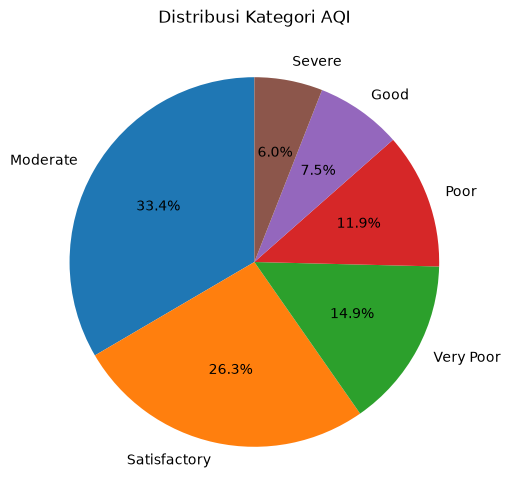

In [23]:
import matplotlib.pyplot as plt

aqi_cat = df['AQI_Bucket'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    aqi_cat.values,
    labels=aqi_cat.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribusi Kategori AQI')
plt.show()

## EDA

### Deskriptif

In [24]:
print(df['AQI_Bucket'].nunique())

6


In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,1941394.0,80.864814,89.476181,0.01,28.16,52.59,97.74,1000.00
PM10,1469831.0,158.483906,139.788258,0.01,64.00,116.25,204.00,1000.00
NO,2035372.0,22.788253,48.461463,0.01,3.05,7.15,18.58,500.00
NO2,2060110.0,35.236891,34.975083,0.01,13.10,24.79,45.48,499.99
NOx,2098275.0,40.551148,55.908938,0.00,11.35,22.86,45.70,500.00
NH3,1352465.0,28.708556,27.532443,0.01,11.23,22.35,37.78,499.97
CO,2089781.0,1.502366,6.292445,0.00,0.41,0.80,1.38,498.57
SO2,1846346.0,12.116025,14.673848,0.01,4.25,8.25,14.53,199.96
O3,1863110.0,38.064085,47.106533,0.01,11.02,24.75,49.53,997.00
Benzene,1727504.0,3.305493,12.140528,0.00,0.08,0.96,3.23,498.07


### Distribusi Data

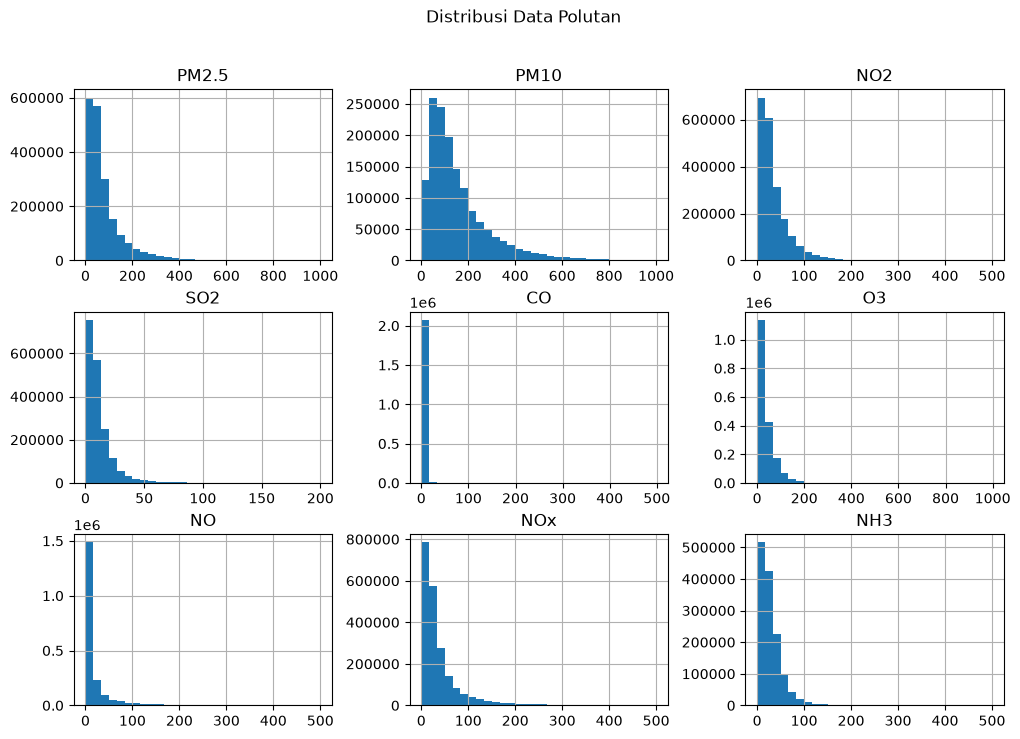

In [26]:
import matplotlib.pyplot as plt

pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'NO', 'NOx', 'NH3']  

df[pollutants].hist(figsize=(12,8), bins=30)
plt.suptitle('Distribusi Data Polutan')
plt.show()

### disribusi pola AQ

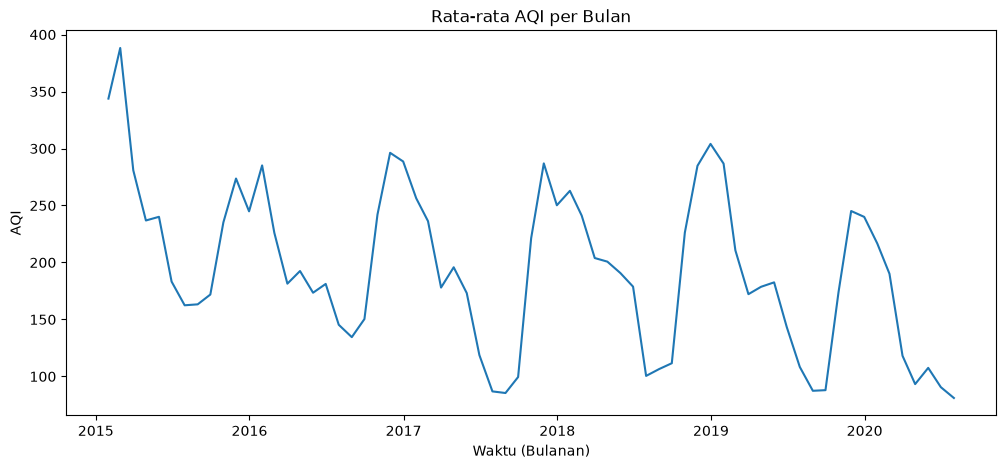

In [28]:
import matplotlib.pyplot as plt

aqi_monthly = df['AQI'].resample('ME').mean()

plt.figure(figsize=(12,5))
plt.plot(aqi_monthly.index, aqi_monthly.values)

plt.title('Rata-rata AQI per Bulan')
plt.xlabel('Waktu (Bulanan)')
plt.ylabel('AQI')

plt.show()

### Lokasi Spasial

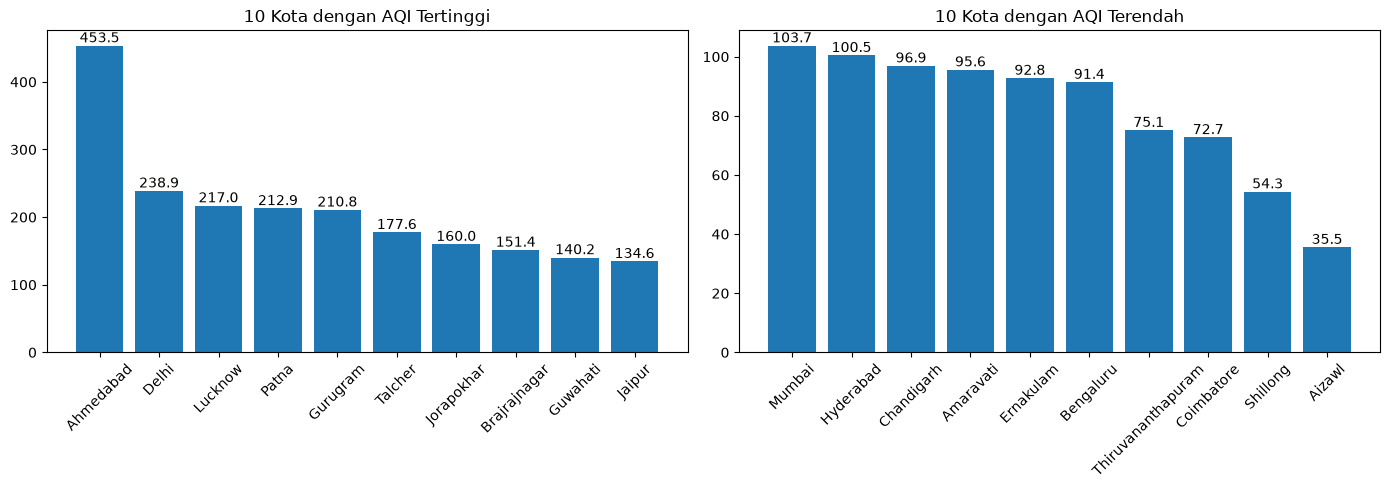

In [29]:
import matplotlib.pyplot as plt

aqi_city = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

top10 = aqi_city.head(10)
bottom10 = aqi_city.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].bar(top10.index, top10.values)
axes[0].set_title('10 Kota dengan AQI Tertinggi')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(top10.values):
    axes[0].text(i, v, f'{v:.1f}', ha='center', va='bottom')

axes[1].bar(bottom10.index, bottom10.values)
axes[1].set_title('10 Kota dengan AQI Terendah')
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(bottom10.values):
    axes[1].text(i, v, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

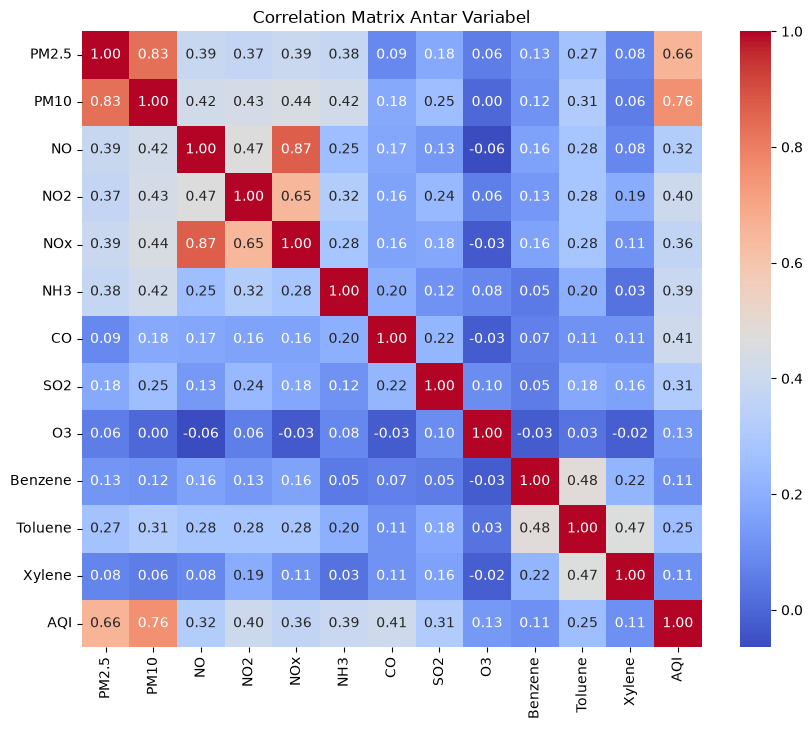

In [30]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')

plt.title('Correlation Matrix Antar Variabel')
plt.show()

### Variabel ke Target

In [31]:
corr = df.corr(numeric_only=True)['AQI'].drop('AQI').sort_values(ascending=False)

top6 = corr.head(6)

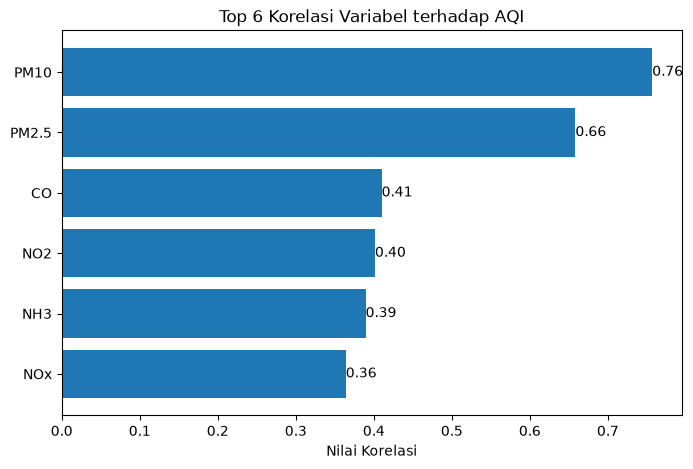

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.barh(top6.index[::-1], top6.values[::-1])

for i, v in enumerate(top6.values[::-1]):
    plt.text(v, i, f'{v:.2f}', va='center')

plt.title('Top 6 Korelasi Variabel terhadap AQI')
plt.xlabel('Nilai Korelasi')

plt.show()